## Data Audit

This section checks the dataset structure and basic data quality before the analysis.

In [248]:
from pathlib import Path

import pandas as pd
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)

project_root = Path.cwd()
if not (project_root / "data").exists():
    project_root = project_root.parent

data_path = project_root / "data" / "wine-quality" / "winequality-white.csv"
figures_dir = project_root / "figures"
figures_dir.mkdir(exist_ok=True)

df = pd.read_csv(data_path, sep=";")#数据之间用的「；」间隔

print(df.shape)
print(df.columns)
print(df.dtypes) #数据类型 float int

print(df.isnull().sum())#先判断是否空值 然后对其计数

print("Duplicated rows:", df.duplicated().sum())#链式方法调用 先是布尔类型判断T==1orF==0然后计数 前一个方法执行过后返回新对象 第二个方法在此对象上执行

print(df.describe().T)#对数据集快速做基础调研





(4898, 12)
Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='str')
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64
Duplicated rows: 937
                      

## Data Audit Findings

- The dataset contains 4,898 samples and 12 variables, including 11 physicochemical features and one `quality` variable.
- There are 0 missing values.
- There are 937 duplicated rows. They are retained because the dataset has no sample identifiers, so identical measurements cannot be confirmed as accidental duplicates.
- The feature scales differ substantially. For example, `total sulfur dioxide`
  has a mean of about 138, while `citric acid` has a mean of about 0.33.
- Wine quality ranges from 3 to 9 and is mainly concentrated around scores 5 and 6.

In [249]:
df["quality"].value_counts()#df["quality"].value_counts().sort_index()从低到高排列

quality
6    2198
5    1457
7     880
8     175
4     163
3      20
9       5
Name: count, dtype: int64

## Exploratory Data Analysis

This section examines the distributions of quality scores and selected physicochemical features.

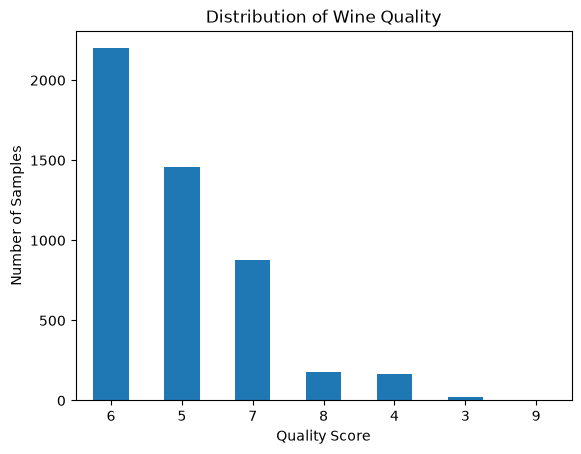

In [250]:
import matplotlib.pyplot as plt

quality_counts = df["quality"].value_counts()

plt.figure(figsize=(6, 4))
quality_counts.plot(kind="bar",rot=0)#柱状图 旋转0

plt.xlabel("Quality Score")#横轴
plt.ylabel("Number of Samples")#纵轴
plt.title("Distribution of Wine Quality")
plt.tight_layout()
plt.savefig(figures_dir / "01_quality_distribution.png", dpi=150, bbox_inches="tight")

plt.show()

### Quality Distribution

Quality scores are highly imbalanced. Scores 5 and 6 account for most samples,
while extreme scores such as 3 and 9 are rare.

The `quality` variable is not used as an input to KMeans, but this imbalance
should still be considered when interpreting the quality distribution of each cluster.

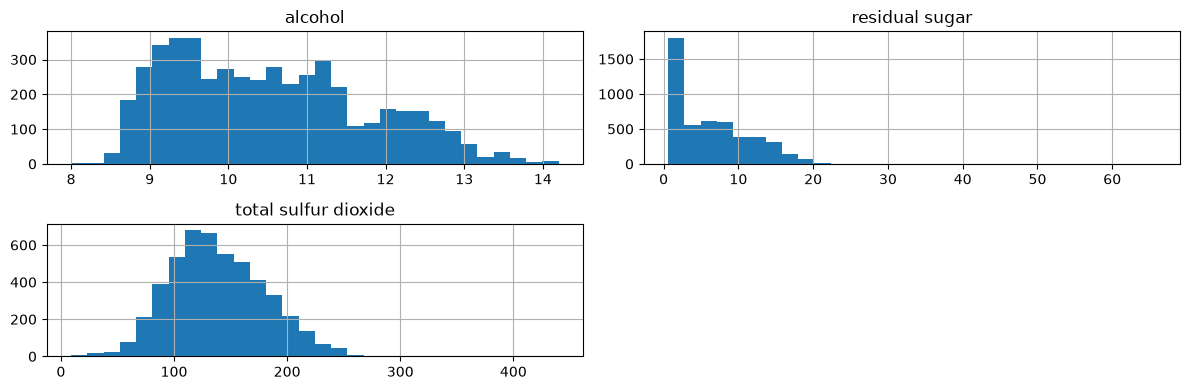

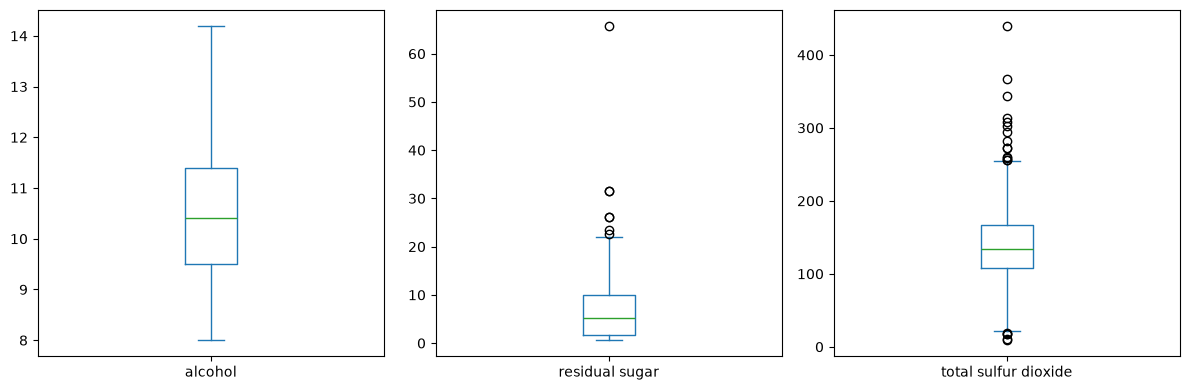

In [251]:
features = ["alcohol", "residual sugar", "total sulfur dioxide"]#三个代表性强的

df[features].hist(bins=30, figsize=(12, 4))#histogram图

plt.tight_layout()#美观提升可读性
plt.savefig(figures_dir / "02_feature_histograms.png", dpi=150, bbox_inches="tight")
plt.show()

df[features].plot(
    kind="box",
    subplots=True,#每个标签单独一张图
    layout=(1, 3),#布局
    figsize=(12, 4),#图大小
    sharey=False#不共用y轴高度
)

plt.tight_layout()
plt.savefig(figures_dir / "03_feature_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

### Feature Distribution Findings

- `total sulfur dioxide` is approximately unimodal and relatively symmetric, although it has a slight right tail.
- `residual sugar` is strongly right-skewed, with most observations at lower values and a small number of very large values.
- The box plots show many potential outliers for `residual sugar` and `total sulfur dioxide`.
- These potential outliers should not be removed automatically because they may represent valid wine samples rather than data errors.

## Feature Relationships

This section uses correlations and scatter plots to examine the strongest feature relationships.

residual sugar        density                 0.838966
density               residual sugar          0.838966
alcohol               density                -0.780138
density               alcohol                -0.780138
total sulfur dioxide  free sulfur dioxide     0.615501
free sulfur dioxide   total sulfur dioxide    0.615501
density               total sulfur dioxide    0.529881
total sulfur dioxide  density                 0.529881
alcohol               residual sugar         -0.450631
residual sugar        alcohol                -0.450631
dtype: float64


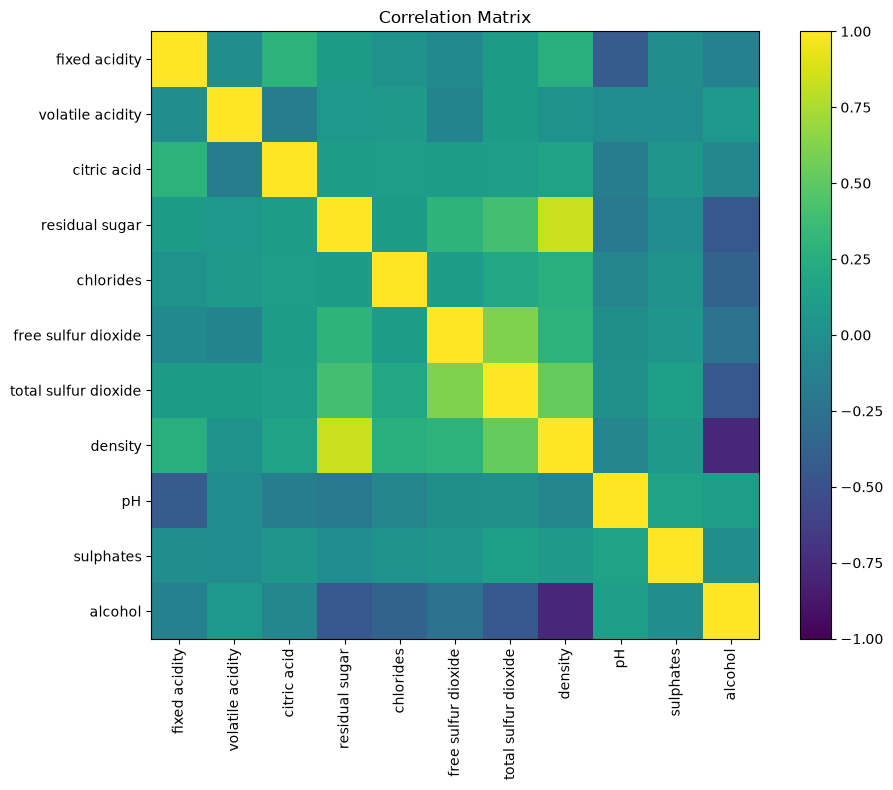

In [252]:
import matplotlib.pyplot as plt

features_only = df.drop(columns="quality")

corr = features_only.corr()#皮尔逊相关系数

corr_pairs = (
    corr.where(~corr.eq(1))
        .stack()
        .sort_values(key=abs, ascending=False)#颜色区分
)

print(corr_pairs.head(10))

fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(corr, vmin=-1, vmax=1)#颜色区间 

fig.colorbar(im, ax=ax)

ax.set_xticks(range(len(corr.columns)))
ax.set_yticks(range(len(corr.columns)))

ax.set_xticklabels(corr.columns, rotation=90)
ax.set_yticklabels(corr.columns)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(figures_dir / "04_correlation_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

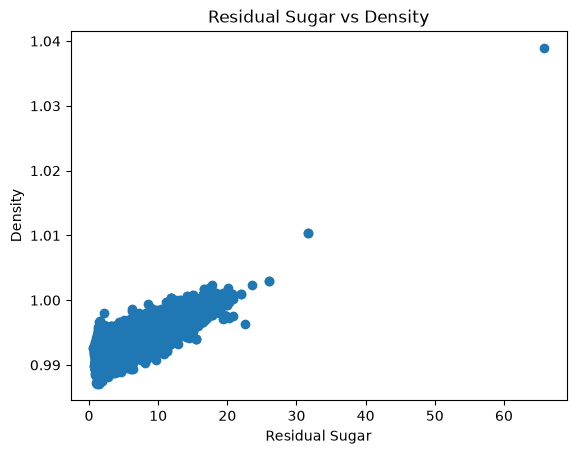

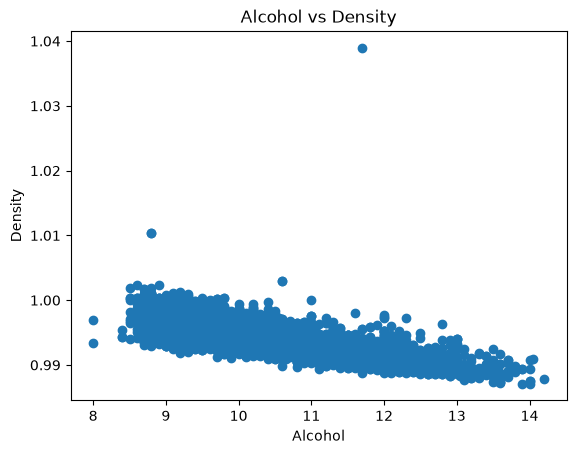

In [253]:
#正相关散点图
plt.figure(figsize=(6, 4))
plt.scatter(df["residual sugar"], df["density"])

plt.xlabel("Residual Sugar")
plt.ylabel("Density")
plt.title("Residual Sugar vs Density")
plt.tight_layout()
plt.savefig(figures_dir / "05_residual_sugar_vs_density.png", dpi=150, bbox_inches="tight")

plt.show()

#负相关
plt.figure(figsize=(6, 4))
plt.scatter(df["alcohol"], df["density"])

plt.xlabel("Alcohol")
plt.ylabel("Density")
plt.title("Alcohol vs Density")
plt.tight_layout()
plt.savefig(figures_dir / "06_alcohol_vs_density.png", dpi=150, bbox_inches="tight")

plt.show()

### Correlation Findings

- `residual sugar` and `density` show a strong positive linear relationship (`r ≈ 0.84`).
- `alcohol` and `density` show a strong negative linear relationship (`r ≈ -0.78`).
- A few extreme observations are visible, especially for `residual sugar`.
- The scatter plots support the direction suggested by the correlation coefficients, but extreme points may also affect the measured correlation.

In [254]:
main_region = df[df["residual sugar"] <= 25]

original_corr = df["residual sugar"].corr(df["density"])
filtered_corr = main_region["residual sugar"].corr(main_region["density"])

print("Original correlation:", original_corr)
print("Filtered correlation:", filtered_corr)

Original correlation: 0.8389664549045834
Filtered correlation: 0.8313806051511028


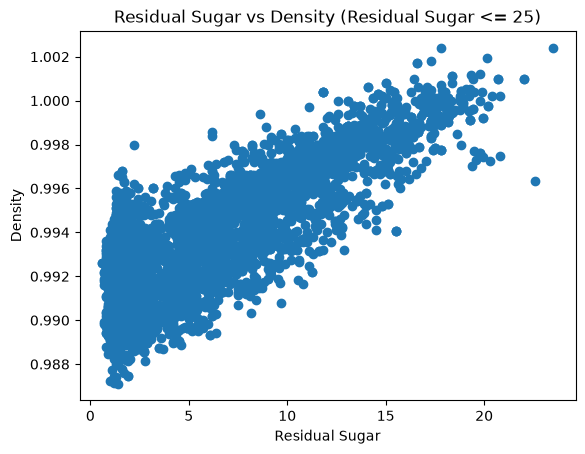

In [255]:
plt.figure(figsize=(6, 4))
plt.scatter(main_region["residual sugar"], main_region["density"])

plt.xlabel("Residual Sugar")
plt.ylabel("Density")
plt.title("Residual Sugar vs Density (Residual Sugar <= 25)")
plt.tight_layout()
plt.savefig(figures_dir / "07_residual_sugar_vs_density_filtered.png", dpi=150, bbox_inches="tight")

plt.show()

> **Q1.** The strongest relationships are between residual sugar and density (`r ≈ 0.84`), alcohol and density (`r ≈ -0.78`), and free and total sulfur dioxide (`r ≈ 0.62`). The residual sugar–density correlation remains strong after limiting residual sugar to 25 or below (`r ≈ 0.83`), suggesting that it is not driven only by a few high-sugar observations.

## Standardization and Cluster Selection

The physicochemical features are standardized before clustering so that variables with larger numerical scales do not dominate the distance calculation. Candidate solutions from `k=2` to `k=8` are then compared before fitting the final model.

In [256]:
features = df.drop(columns="quality")

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)#计算每一列的 mean 和 std然后转化为标准化后的值

#验证 mean约为0 std约为1
scaled_df = pd.DataFrame(
    scaled_features,
    columns=features.columns
)

print(scaled_df.mean())
print(scaled_df.std())

fixed acidity          -3.481630e-16
volatile acidity        4.497106e-16
citric acid             1.160543e-17
residual sugar         -1.066249e-16
chlorides               3.133467e-16
free sulfur dioxide    -1.015476e-17
total sulfur dioxide   -4.642174e-17
density                 3.247201e-14
pH                     -1.183754e-15
sulphates              -8.218098e-16
alcohol                -3.713739e-16
dtype: float64
fixed acidity           1.000102
volatile acidity        1.000102
citric acid             1.000102
residual sugar          1.000102
chlorides               1.000102
free sulfur dioxide     1.000102
total sulfur dioxide    1.000102
density                 1.000102
pH                      1.000102
sulphates               1.000102
alcohol                 1.000102
dtype: float64


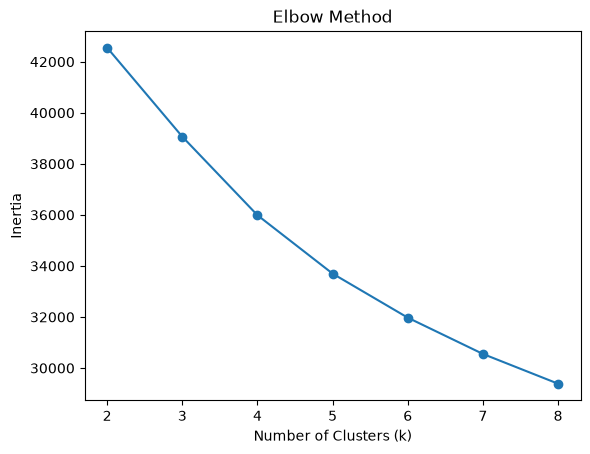

In [259]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertias = []#每个聚类里面求到中心的平方距离之和
#不是越小越好 k为样本量 该值可以为0 注意该值下降明显缓慢的拐点

k_values = range(2, 9)

for k in k_values: #训练多个k 观察拐点
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(scaled_df)
    inertias.append(model.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(k_values, inertias, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.tight_layout()
plt.savefig(figures_dir / "08_elbow_method.png", dpi=150, bbox_inches="tight")

plt.show()

[0.2144765606038808, 0.14466254062907263, 0.1589253493041533, 0.14397316711385863, 0.14664494026317712, 0.12566133309990926, 0.12382774451109188]


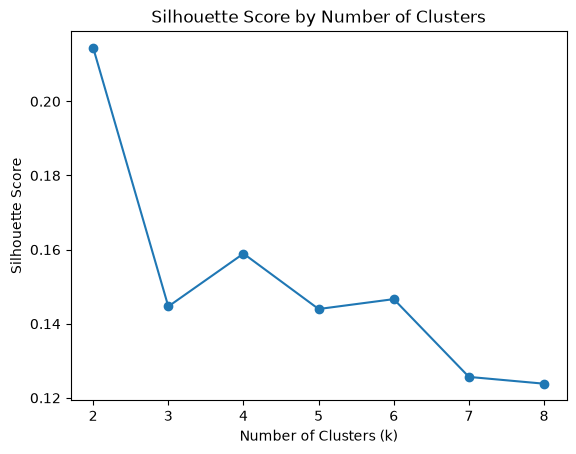

In [260]:
#Silhouette Score看每个聚类里面的点离其他的点有多近/远 离其他聚类有多远
from sklearn.metrics import silhouette_score

silhouette_scores = []

k_values = range(2, 9)

for k in k_values:
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(scaled_df)

    score = silhouette_score(scaled_df, labels)

    silhouette_scores.append(score)

print(silhouette_scores)

plt.figure(figsize=(7, 4))
plt.plot(k_values, silhouette_scores, marker="o")

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score by Number of Clusters")
plt.tight_layout()
plt.savefig(figures_dir / "09_silhouette_scores.png", dpi=150, bbox_inches="tight")

plt.show()

Among the tested values from `k=2` to `k=8`, `k=2` has the highest silhouette score. However, the score is relatively low (`≈ 0.214`), indicating weak separation between clusters.

In [261]:
#以k=2分析
final_kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

final_labels = final_kmeans.fit_predict(scaled_df)

df_clustered = df.copy()
df_clustered["cluster"] = final_labels

df_clustered["cluster"].value_counts().sort_index()

print (df_clustered["cluster"].value_counts().sort_index())

final_centers = pd.DataFrame(
    final_kmeans.cluster_centers_,
    columns=features.columns
)

final_centers

cluster
0    1957
1    2941
Name: count, dtype: int64


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
0,0.177063,0.046377,0.233972,0.848161,0.396764,0.597967,0.765819,0.947840,-0.200617,0.059643,-0.790431
1,-0.117821,-0.030860,-0.155689,-0.564383,-0.264015,-0.397899,-0.509591,-0.630712,0.133494,-0.039688,0.525969


- Cluster 0: higher residual sugar, density, and sulfur dioxide, with lower alcohol.
- Cluster 1: lower residual sugar, density, and sulfur dioxide, with higher alcohol and pH.

> **Q2.** After standardization, KMeans with `k=2` produces the clearest separation among the tested values according to the silhouette score. However, the relatively low score suggests that the dataset does not contain strongly separated natural clusters. The two groups are better interpreted as broad physicochemical profiles.

## Quality Comparison After Clustering
Quality was not used as an input to KMeans. It is compared only after the clusters have been formed.

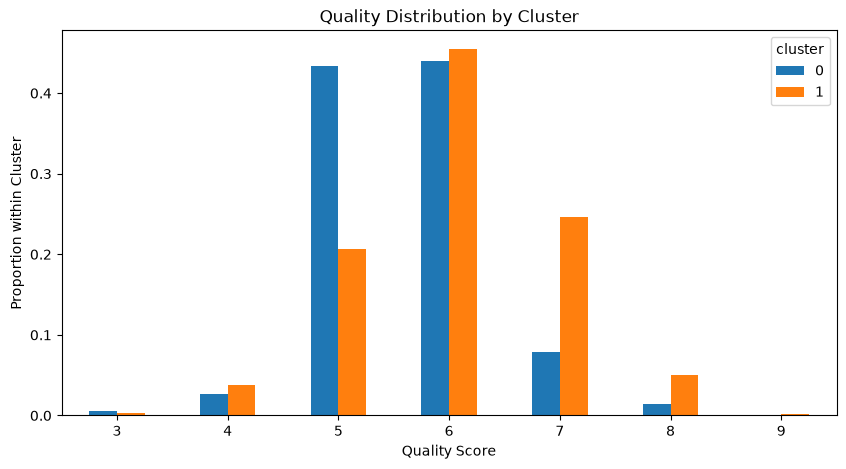

In [262]:
#每个簇里面的数量不一样 计算比例
quality_by_cluster = pd.crosstab(
    df_clustered["cluster"],
    df_clustered["quality"],
    normalize="index"
)

quality_by_cluster

quality_by_cluster.T.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.xlabel("Quality Score")
plt.ylabel("Proportion within Cluster")
plt.title("Quality Distribution by Cluster")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(figures_dir / "10_quality_distribution_by_cluster.png", dpi=150, bbox_inches="tight")

plt.show()

In [263]:
quality_summary = df_clustered.groupby("cluster")["quality"].agg(
    ["count", "mean", "median"]
)

print(quality_summary)

high_quality_share = (
    df_clustered.assign(high_quality=df_clustered["quality"] >= 7)
    .groupby("cluster")["high_quality"]
    .mean()
)

high_quality_share

         count      mean  median
cluster                         
0         1957  5.603475     6.0
1         2941  6.060524     6.0


cluster
0    0.094021
1    0.297858
Name: high_quality, dtype: float64

> **Q3.** Cluster 1 shows a stronger tendency toward higher quality scores: about 29.8% of its samples have scores of 7 or above, compared with about 9.4% in Cluster 0. However, both clusters have a median quality score of 6 and substantial overlap, so they should not be interpreted as simple high- and low-quality groups.

## Conclusion

- Residual sugar and density have the strongest positive relationship, while alcohol and density have the strongest negative relationship.
- Among the tested values, `k=2` has the highest silhouette score, but the low score indicates only weak cluster separation.
- Cluster 1 has a higher average quality score and a larger proportion of scores of 7 or above, although the quality distributions still overlap substantially.

Overall, the clustering reveals broad physicochemical profiles rather than sharply separated wine categories. Quality was used only to compare the completed clusters, not to construct them.

## Limitations

- The silhouette score is low (`≈ 0.214`), so the clusters should be treated as exploratory profiles rather than clear natural groups.
- KMeans results depend on feature scaling, the selected value of `k`, and the features included.
- The 937 duplicated rows were retained because the dataset has no sample identifiers. Some may be valid repeated observations, but they may still affect the results.
- Quality scores are imbalanced and partly subjective, and the threshold of 7 is used only as a descriptive summary.
- The results show associations rather than causal relationships and apply only to this white wine dataset.
- Cluster labels such as 0 and 1 are arbitrary and do not have fixed meanings.